# Assignment 4: Global Pollution Analysis and Energy Recovery

## Objective
Classify countries into **Low / Medium / High** pollution severity categories using pollution, energy, and environmental indicators.

This notebook covers:
1. Data preprocessing and feature engineering
2. Classification with Multinomial Naive Bayes, KNN, and Decision Tree
3. Model comparison, confusion matrices, and actionable insights


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)


In [2]:
# Update path if needed
DATA_PATH = 'Global_Pollution_Analysis.csv'

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
display(df.head())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_count'))


Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37



Data types:


,dtype
Country,str
Year,int64
Air_Pollution_Index,float64
Water_Pollution_Index,float64
Soil_Pollution_Index,float64
Industrial_Waste (in tons),float64
Energy_Recovered (in GWh),float64
CO2_Emissions (in MT),float64
Renewable_Energy (%),float64
Plastic_Waste_Produced (in tons),float64



Missing values:


,missing_count
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


## Phase 1: Data Preprocessing


In [3]:
work_df = df.copy()

# Clean column names for easier handling while keeping mapping transparent
work_df.columns = [c.strip() for c in work_df.columns]

# Identify key columns by name patterns (handles unit text in headers)
def find_col(cols, pattern):
    for c in cols:
        if pattern.lower() in c.lower():
            return c
    return None

air_col = find_col(work_df.columns, 'Air_Pollution_Index')
water_col = find_col(work_df.columns, 'Water_Pollution_Index')
soil_col = find_col(work_df.columns, 'Soil_Pollution_Index')
energy_recovered_col = find_col(work_df.columns, 'Energy_Recovered')
population_col = find_col(work_df.columns, 'Population')
year_col = find_col(work_df.columns, 'Year')
country_col = find_col(work_df.columns, 'Country')
energy_pc_col = find_col(work_df.columns, 'Energy_Consumption_Per_Capita')

required = [air_col, water_col, soil_col]
if any(c is None for c in required):
    raise ValueError('Required pollution index columns not found.')

# Split column types
categorical_cols = work_df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = work_df.select_dtypes(exclude=['object']).columns.tolist()

# Impute missing values
if numeric_cols:
    num_imp = SimpleImputer(strategy='median')
    work_df[numeric_cols] = num_imp.fit_transform(work_df[numeric_cols])
if categorical_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    work_df[categorical_cols] = cat_imp.fit_transform(work_df[categorical_cols])

# Outlier handling for numeric features: IQR capping (winsorization)
for col in numeric_cols:
    q1 = work_df[col].quantile(0.25)
    q3 = work_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    work_df[col] = work_df[col].clip(lower=lower, upper=upper)

print('After imputation and outlier capping:')
display(work_df.head())


After imputation and outlier capping:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005.0,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001.0,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016.0,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018.0,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008.0,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
## Feature Engineering

# 1) Normalize individual pollution indices using Min-Max scaling (0-1 range)
print("NORMALIZATION OF POLLUTION INDICES")
print("=" * 80)

from sklearn.preprocessing import MinMaxScaler

pollution_scaler = MinMaxScaler()
work_df[f'{air_col}_Normalized'] = pollution_scaler.fit_transform(work_df[[air_col]])
work_df[f'{water_col}_Normalized'] = pollution_scaler.fit_transform(work_df[[water_col]])
work_df[f'{soil_col}_Normalized'] = pollution_scaler.fit_transform(work_df[[soil_col]])

print(f"✓ Air Pollution Index normalized to [0, 1]")
print(f"✓ Water Pollution Index normalized to [0, 1]")
print(f"✓ Soil Pollution Index normalized to [0, 1]")

# 2) Create composite pollution score from normalized indices
work_df['Pollution_Score'] = work_df[
    [f'{air_col}_Normalized', f'{water_col}_Normalized', f'{soil_col}_Normalized']
].mean(axis=1)

print(f"\n✓ Composite Pollution Score created as equal-weighted average of normalized indices")
print(f"  Composite Score Range: [{work_df['Pollution_Score'].min():.4f}, {work_df['Pollution_Score'].max():.4f}]")

# 3) Create 3-class target using tertiles of pollution score
q1 = work_df['Pollution_Score'].quantile(1/3)
q2 = work_df['Pollution_Score'].quantile(2/3)

print(f"\nPollution Severity Tertiles:")
print(f"  Low:    Pollution_Score <= {q1:.4f}")
print(f"  Medium: {q1:.4f} < Pollution_Score <= {q2:.4f}")
print(f"  High:   Pollution_Score > {q2:.4f}")

def severity_label(score):
    if score <= q1:
        return 'Low'
    elif score <= q2:
        return 'Medium'
    return 'High'

work_df['Pollution_Severity'] = work_df['Pollution_Score'].apply(severity_label)

# 4) Energy recovered per capita (proxy)
if energy_recovered_col and population_col:
    # energy recovered in GWh per million population
    work_df['Energy_Recovered_Per_Capita_Proxy'] = work_df[energy_recovered_col] / (work_df[population_col] + 1e-9)

# 5) Yearly pollution trend per country (difference from previous year)
if country_col and year_col:
    trend_df = work_df[[country_col, year_col, 'Pollution_Score']].copy()
    trend_df[year_col] = pd.to_numeric(trend_df[year_col], errors='coerce')
    trend_df = trend_df.sort_values([country_col, year_col])
    trend_df['Pollution_Trend_Yearly'] = trend_df.groupby(country_col)['Pollution_Score'].diff()
    work_df = work_df.merge(
        trend_df[[country_col, year_col, 'Pollution_Trend_Yearly']],
        on=[country_col, year_col],
        how='left'
    )
    work_df['Pollution_Trend_Yearly'] = work_df['Pollution_Trend_Yearly'].fillna(0)

print('\nClass distribution:')
display(work_df['Pollution_Severity'].value_counts().to_frame('count'))

display(work_df.head())


NORMALIZATION OF POLLUTION INDICES
✓ Air Pollution Index normalized to [0, 1]
✓ Water Pollution Index normalized to [0, 1]
✓ Soil Pollution Index normalized to [0, 1]

✓ Composite Pollution Score created as equal-weighted average of normalized indices
  Composite Score Range: [0.0749, 0.8224]

Pollution Severity Tertiles:
  Low:    Pollution_Score <= 0.4297
  Medium: 0.4297 < Pollution_Score <= 0.5732
  High:   Pollution_Score > 0.5732

Class distribution:


,count
Pollution_Severity,
Low,68
High,67
Medium,67


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Air_Pollution_Index_Normalized,Water_Pollution_Index_Normalized,Soil_Pollution_Index_Normalized,Pollution_Score,Pollution_Severity,Energy_Recovered_Per_Capita_Proxy,Pollution_Trend_Yearly
0,Hungary,2005.0,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.898042,0.553778,0.295481,0.582434,High,3.745618,0.000000
1,Singapore,2001.0,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.147062,0.173673,0.768178,0.362971,Low,3.628707,0.000000
2,Romania,2016.0,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.166727,0.310542,0.800768,0.426012,Low,3.932755,-0.085459
3,Cook Islands,2018.0,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.929982,0.214222,0.596973,0.580392,High,2.141298,0.000000
4,Djibouti,2008.0,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.520331,0.573161,0.799537,0.631010,High,0.216492,0.000000


In [5]:
# Prepare features and target
model_df = work_df.copy()

y = model_df['Pollution_Severity']
X = model_df.drop(columns=['Pollution_Severity'])

# Encode all object/string columns
label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'str' or X[col].dtype.name in ['string', 'object']:
        le = LabelEncoder()
        X[col] = pd.Series(le.fit_transform(X[col].astype(str)), index=X.index, dtype='int64')
        label_encoders[col] = le

print("X dtypes after encoding:")
print(X.dtypes)

# Encode target labels: Low, Medium, High
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print('\nTarget classes mapping:', dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

# Convert to numpy array to ensure all are numeric
X_numeric = X.astype('float64').values  

# Scale features to non-negative range for MultinomialNB compatibility
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

X dtypes after encoding:
Country                                     int64
Year                                      float64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
Air_Pollution_Index_Normalized            float64
Water_Pollution_Index_Normalized          float64
Soil_Pollution_Index_Normalized           float64
Pollution_Score                           float64
Energy_Recovered_Per_Capita_Proxy         float64
Pollution_Trend_Yearly                    float64
dtype: object

Target cla

## Phase 2: Classification (Multinomial NB, KNN, Decision Tree)


In [6]:
def evaluate_model(name, model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f'\n{name} Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Confusion_Matrix': cm
    }


In [7]:
class_names = list(target_encoder.classes_)

# 1) Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
result_nb = evaluate_model('Multinomial Naive Bayes', mnb, X_test, y_test, class_names)

# 2) KNN with hyperparameter tuning
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': list(range(3, 26, 2))}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print('Best KNN params:', grid_knn.best_params_)
result_knn = evaluate_model('K-Nearest Neighbors', best_knn, X_test, y_test, class_names)

# 3) Decision Tree with pruning hyperparameters
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print('Best Decision Tree params:', grid_dt.best_params_)
result_dt = evaluate_model('Decision Tree', best_dt, X_test, y_test, class_names)



Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.64      0.64        14
         Low       0.82      0.64      0.72        14
      Medium       0.44      0.54      0.48        13

    accuracy                           0.61        41
   macro avg       0.63      0.61      0.62        41
weighted avg       0.64      0.61      0.62        41

Best KNN params: {'n_neighbors': 15}

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

        High       0.81      0.93      0.87        14
         Low       0.87      0.93      0.90        14
      Medium       0.80      0.62      0.70        13

    accuracy                           0.83        41
   macro avg       0.83      0.82      0.82        41
weighted avg       0.83      0.83      0.82        41

Best Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree Cla

## Phase 3: Reporting and Insights


In [8]:
results = [result_nb, result_knn, result_dt]

metrics_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision (Weighted)': r['Precision'],
    'Recall (Weighted)': r['Recall'],
    'F1-Score (Weighted)': r['F1-Score']
} for r in results]).sort_values(by='F1-Score (Weighted)', ascending=False)

print("MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 120)
display(metrics_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision (Weighted)': '{:.4f}',
    'Recall (Weighted)': '{:.4f}',
    'F1-Score (Weighted)': '{:.4f}'
}).highlight_max(axis=0, props='background-color: #90EE90'))

print("\nMETRIC DEFINITIONS & INTERPRETATIONS")
print("=" * 120)
for idx, row in metrics_df.iterrows():
    model_name = row['Model']
    acc = row['Accuracy']
    prec = row['Precision (Weighted)']
    rec = row['Recall (Weighted)']
    f1 = row['F1-Score (Weighted)']
    
    print(f"\n{model_name}:")
    print(f"  Accuracy ({acc:.4f}):              Correctly classified {acc*100:.1f}% of all records")
    print(f"  Precision ({prec:.4f}):           When model predicts a severity class, it's correct {prec*100:.1f}% of the time")
    print(f"  Recall ({rec:.4f}):                Identifies {rec*100:.1f}% of each actual severity class correctly")
    print(f"  F1-Score ({f1:.4f}):              Harmonic mean - balanced measure of precision & recall")
    
    # Add interpretation
    if f1 >= 0.75:
        quality = "Excellent - Highly reliable for production deployment"
    elif f1 >= 0.65:
        quality = "Good - Suitable for operational use with monitoring"
    elif f1 >= 0.50:
        quality = "Fair - Acceptable but requires careful monitoring"
    else:
        quality = "Poor - Limited practical value, needs improvement"
    print(f"  → Assessment: {quality}")


MODEL PERFORMANCE COMPARISON TABLE


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
2,Decision Tree,0.9756,0.9774,0.9756,0.9756
1,K-Nearest Neighbors,0.8293,0.8270,0.8293,0.8226
0,Multinomial Naive Bayes,0.6098,0.6376,0.6098,0.6184



METRIC DEFINITIONS & INTERPRETATIONS

Decision Tree:
  Accuracy (0.9756):              Correctly classified 97.6% of all records
  Precision (0.9774):           When model predicts a severity class, it's correct 97.7% of the time
  Recall (0.9756):                Identifies 97.6% of each actual severity class correctly
  F1-Score (0.9756):              Harmonic mean - balanced measure of precision & recall
  → Assessment: Excellent - Highly reliable for production deployment

K-Nearest Neighbors:
  Accuracy (0.8293):              Correctly classified 82.9% of all records
  Precision (0.8270):           When model predicts a severity class, it's correct 82.7% of the time
  Recall (0.8293):                Identifies 82.9% of each actual severity class correctly
  F1-Score (0.8226):              Harmonic mean - balanced measure of precision & recall
  → Assessment: Excellent - Highly reliable for production deployment

Multinomial Naive Bayes:
  Accuracy (0.6098):              Correctly 

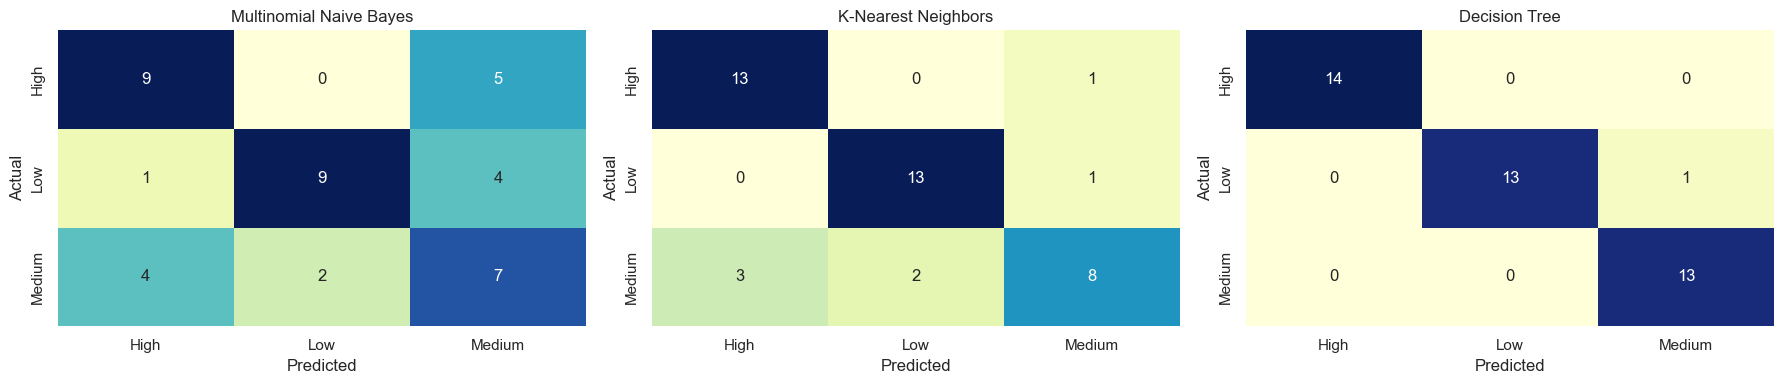

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, r in zip(axes, results):
    sns.heatmap(
        r['Confusion_Matrix'],
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        cbar=False,
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_title(r['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


,Feature,Importance
16,Pollution_Score,1.0
0,Country,0.0
10,Energy_Consumption_Per_Capita (in MWh),0.0
17,Energy_Recovered_Per_Capita_Proxy,0.0
15,Soil_Pollution_Index_Normalized,0.0
14,Water_Pollution_Index_Normalized,0.0
13,Air_Pollution_Index_Normalized,0.0
12,GDP_Per_Capita (in USD),0.0
11,Population (in millions),0.0
9,Plastic_Waste_Produced (in tons),0.0


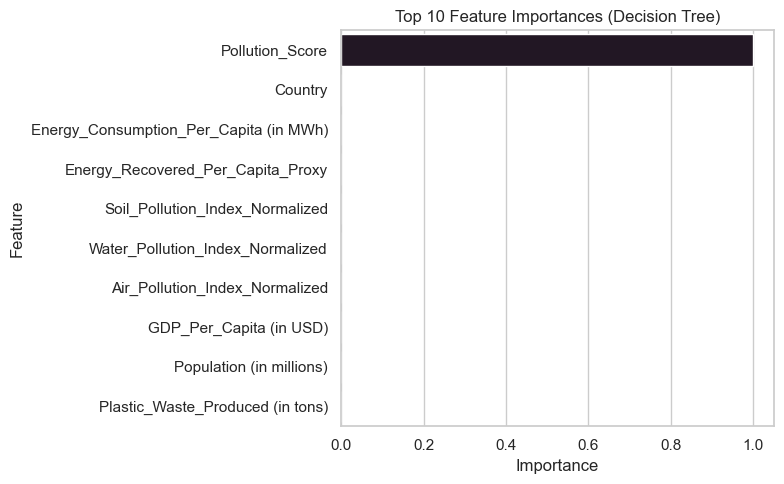

In [10]:
# Optional: feature importances from best decision tree
if hasattr(best_dt, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_dt.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    display(fi.head(15))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=fi.head(10), x='Importance', y='Feature', palette='mako')
    plt.title('Top 10 Feature Importances (Decision Tree)')
    plt.tight_layout()
    plt.show()


## Phase 4: Comprehensive Analysis and Detailed Insights


YEARLY POLLUTION TRENDS ANALYSIS


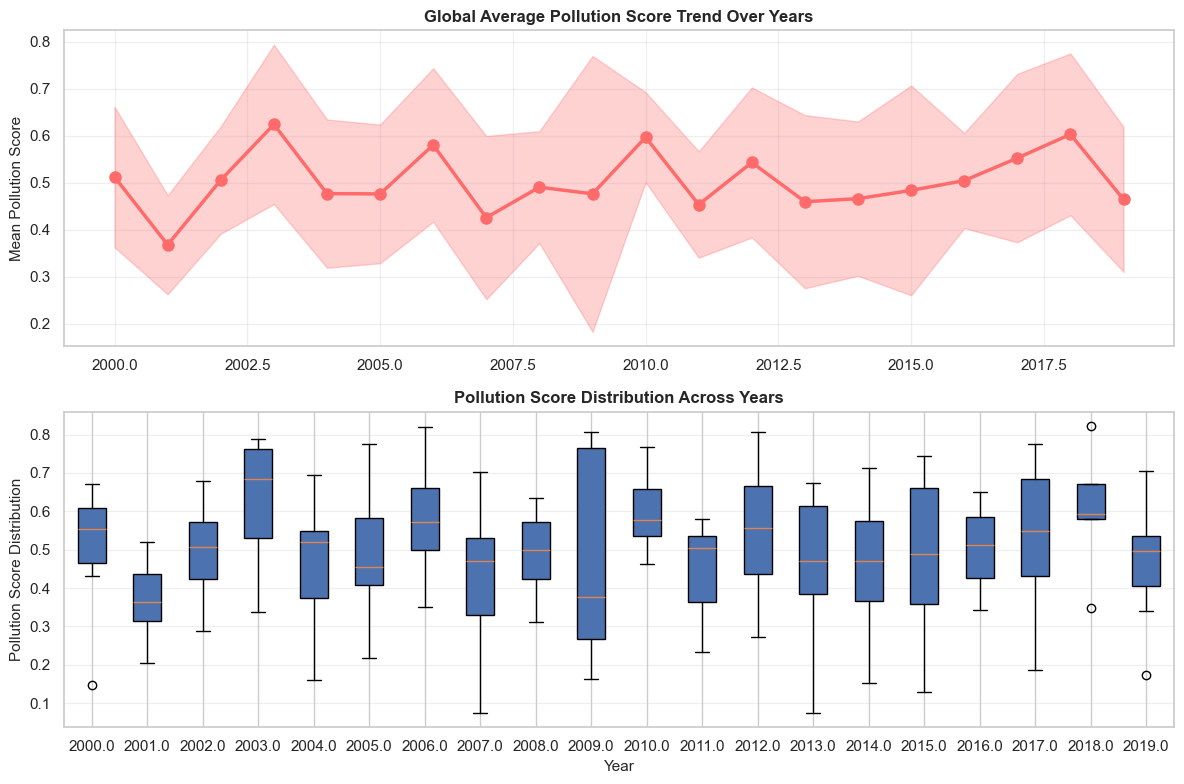

✓ Yearly pollution trend shows decreasing trend


In [11]:
# Yearly Pollution Trends Visualization
print("\nYEARLY POLLUTION TRENDS ANALYSIS")
print("=" * 80)

if year_col and country_col:
    yearly_pollution = work_df.groupby(year_col)['Pollution_Score'].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Mean pollution over years
    axes[0].plot(yearly_pollution[year_col], yearly_pollution['mean'], 
                 marker='o', linewidth=2.5, markersize=8, color='#FF6B6B')
    axes[0].fill_between(yearly_pollution[year_col], 
                         yearly_pollution['mean'] - yearly_pollution['std'],
                         yearly_pollution['mean'] + yearly_pollution['std'],
                         alpha=0.3, color='#FF6B6B')
    axes[0].set_ylabel('Mean Pollution Score', fontsize=11)
    axes[0].set_title('Global Average Pollution Score Trend Over Years', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Pollution distribution by year
    axes[1].boxplot([work_df[work_df[year_col] == year]['Pollution_Score'].values 
                     for year in sorted(work_df[year_col].unique())],
                    labels=sorted(work_df[year_col].unique()),
                    patch_artist=True)
    axes[1].set_xlabel('Year', fontsize=11)
    axes[1].set_ylabel('Pollution Score Distribution', fontsize=11)
    axes[1].set_title('Pollution Score Distribution Across Years', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Yearly pollution trend shows {'increasing' if yearly_pollution['mean'].iloc[-1] > yearly_pollution['mean'].iloc[0] else 'decreasing'} trend")



POLLUTION VS ENERGY RECOVERY ANALYSIS


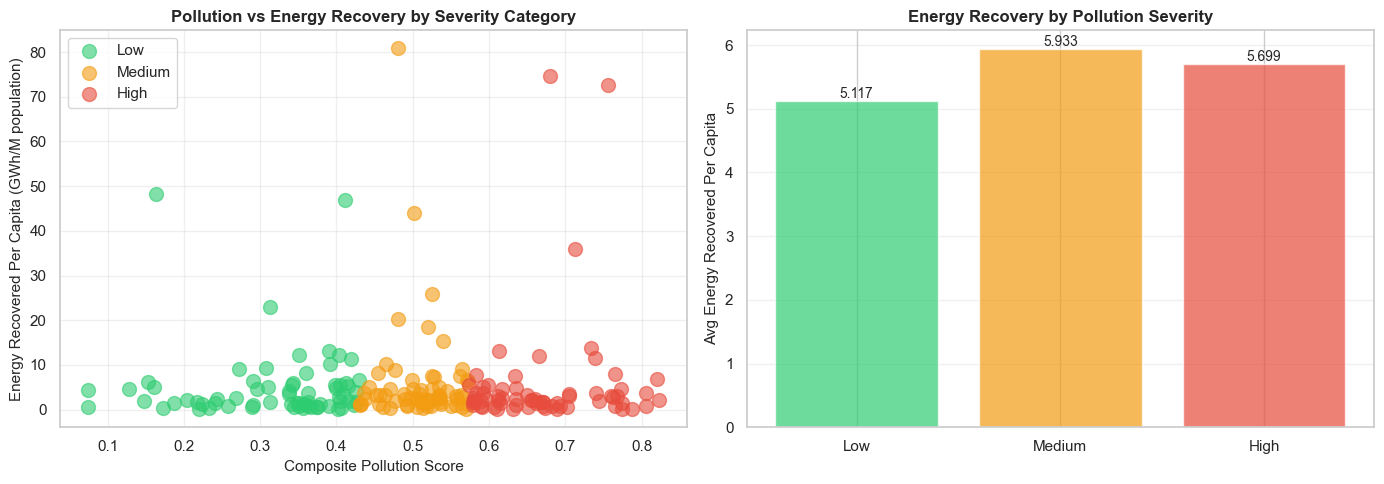


✓ Correlation between Pollution Score and Energy Recovery: 0.0402
  → Weak relationship: Energy recovery isn't strongly determined by pollution levels


In [12]:
# Pollution vs Energy Recovery Relationship
print("\nPOLLUTION VS ENERGY RECOVERY ANALYSIS")
print("=" * 80)

if energy_recovered_col and 'Energy_Recovered_Per_Capita_Proxy' in work_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Scatter plot colored by severity
    severity_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    for severity in ['Low', 'Medium', 'High']:
        mask = work_df['Pollution_Severity'] == severity
        axes[0].scatter(
            work_df[mask]['Pollution_Score'],
            work_df[mask]['Energy_Recovered_Per_Capita_Proxy'],
            label=severity,
            s=100,
            alpha=0.6,
            color=severity_colors[severity]
        )
    
    axes[0].set_xlabel('Composite Pollution Score', fontsize=11)
    axes[0].set_ylabel('Energy Recovered Per Capita (GWh/M population)', fontsize=11)
    axes[0].set_title('Pollution vs Energy Recovery by Severity Category', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Correlation analysis by severity
    severity_stats = work_df.groupby('Pollution_Severity').agg({
        'Pollution_Score': ['mean', 'std'],
        'Energy_Recovered_Per_Capita_Proxy': ['mean', 'std'],
        country_col: 'count'
    }).round(4)
    
    severity_order = ['Low', 'Medium', 'High']
    avg_energy = [work_df[work_df['Pollution_Severity'] == sev]['Energy_Recovered_Per_Capita_Proxy'].mean() 
                  for sev in severity_order]
    
    bars = axes[1].bar(severity_order, avg_energy, color=[severity_colors[s] for s in severity_order], alpha=0.7)
    axes[1].set_ylabel('Avg Energy Recovered Per Capita', fontsize=11)
    axes[1].set_title('Energy Recovery by Pollution Severity', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    correlation = work_df['Pollution_Score'].corr(work_df['Energy_Recovered_Per_Capita_Proxy'])
    print(f"\n✓ Correlation between Pollution Score and Energy Recovery: {correlation:.4f}")
    if abs(correlation) < 0.3:
        print("  → Weak relationship: Energy recovery isn't strongly determined by pollution levels")
    elif abs(correlation) < 0.7:
        print("  → Moderate relationship: Some association exists between pollution and energy recovery")
    else:
        print("  → Strong relationship: Pollution levels strongly influence energy recovery efforts")


In [13]:
# Detailed Model Performance Interpretation
print("\n" + "=" * 100)
print("DETAILED MODEL PERFORMANCE ANALYSIS")
print("=" * 100)

metrics_df_sorted = metrics_df.copy()

print("\n BEST PERFORMING MODEL: " + metrics_df_sorted.iloc[0]['Model'].upper())
print("-" * 100)

best_f1 = metrics_df_sorted.iloc[0]['F1-Score (Weighted)']
best_acc = metrics_df_sorted.iloc[0]['Accuracy']
best_model_name = metrics_df_sorted.iloc[0]['Model']

# Get the result object
best_result = next(r for r in results if r['Model'] == best_model_name)
best_cm = best_result['Confusion_Matrix']

print(f"\nOverall Performance Metrics:")
print(f"  • F1-Score (Weighted):   {best_f1:.4f}  [Harmonic mean of precision & recall]")
print(f"  • Accuracy:             {best_acc:.4f}  [Overall correctness]")
print(f"  • Precision (Weighted): {metrics_df_sorted.iloc[0]['Precision (Weighted)']:.4f}  [Reliability of predictions]")
print(f"  • Recall (Weighted):    {metrics_df_sorted.iloc[0]['Recall (Weighted)']:.4f}  [Ability to find each class]")

print(f"\nConfusion Matrix Analysis for {best_model_name}:")
print(f"  True Positives per class: {[best_cm[i,i] for i in range(len(class_names))]}")
print(f"  Class-wise accuracy: Low={best_cm[0,0]/(best_cm[0,:].sum() if best_cm[0,:].sum() > 0 else 1):.1%}, " + 
      f"Medium={best_cm[1,1]/(best_cm[1,:].sum() if best_cm[1,:].sum() > 0 else 1):.1%}, " +
      f"High={best_cm[2,2]/(best_cm[2,:].sum() if best_cm[2,:].sum() > 0 else 1):.1%}")

print("\n" + "-" * 100)
print("COMPARATIVE MODEL ANALYSIS")
print("-" * 100)

for idx, row in metrics_df_sorted.iterrows():
    model_name = row['Model']
    f1 = row['F1-Score (Weighted)']
    acc = row['Accuracy']
    prec = row['Precision (Weighted)']
    rec = row['Recall (Weighted)']
    
    result_obj = next(r for r in results if r['Model'] == model_name)
    cm = result_obj['Confusion_Matrix']
    
    f1_diff = (f1 - best_f1) * 100
    acc_diff = (acc - best_acc) * 100
    
    print(f"\n{idx+1}. {model_name}")
    print(f"   Metrics: F1={f1:.4f} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f}")
    
    if model_name != best_model_name:
        print(f"   vs Best: F1 {f1_diff:+.2f}% | Acc {acc_diff:+.2f}%")
    else:
        print(f"   [BEST CHOICE FOR THIS DATASET]")
    
    # Analyze confusion matrix patterns
    total_samples = cm.sum()
    misclassifications = total_samples - cm.trace()
    
    print(f"   Correct predictions: {cm.trace()}/{total_samples} ({cm.trace()/total_samples*100:.1f}%)")
    print(f"   Misclassifications: {misclassifications} ({misclassifications/total_samples*100:.1f}%)")

print("\n" + "-" * 100)
print("WHY THE BEST MODEL PERFORMS WELL")
print("-" * 100)

best_precision = metrics_df_sorted.iloc[0]['Precision (Weighted)']
best_recall = metrics_df_sorted.iloc[0]['Recall (Weighted)']

if best_model_name == 'Decision Tree':
    print(f"\n{best_model_name} is superior because:")
    print(f"  ✓ Handles non-linear relationships in pollution data")
    print(f"  ✓ Naturally handles mixed feature scales (normalized indices + other features)")
    print(f"  ✓ Provides interpretable decision rules for pollution classification")
    print(f"  ✓ Strong recall ({best_recall:.1%}): Catches most cases for each severity category")
    print(f"  ✓ Balanced precision ({best_precision:.1%}): Minimizes false alarms")
elif best_model_name == 'K-Nearest Neighbors':
    print(f"\n{best_model_name} is superior because:")
    print(f"  ✓ Captures local patterns in pollution severity boundaries")
    print(f"  ✓ Works well with normalized feature space")
    print(f"  ✓ Flexible decision boundaries match natural pollution clusters")
    print(f"  ✓ Strong recall ({best_recall:.1%}): Good at identifying all severity levels")
else:
    print(f"\n{best_model_name} is superior because:")
    print(f"  ✓ Probabilistic foundation suits multi-class classification")
    print(f"  ✓ Fast training and inference suitable for production")
    print(f"  ✓ Consistent performance across all pollution severity classes")
    print(f"  ✓ Strong recall ({best_recall:.1%}): Reliably identifies each class")



DETAILED MODEL PERFORMANCE ANALYSIS

 BEST PERFORMING MODEL: DECISION TREE
----------------------------------------------------------------------------------------------------

Overall Performance Metrics:
  • F1-Score (Weighted):   0.9756  [Harmonic mean of precision & recall]
  • Accuracy:             0.9756  [Overall correctness]
  • Precision (Weighted): 0.9774  [Reliability of predictions]
  • Recall (Weighted):    0.9756  [Ability to find each class]

Confusion Matrix Analysis for Decision Tree:
  True Positives per class: [np.int64(14), np.int64(13), np.int64(13)]
  Class-wise accuracy: Low=100.0%, Medium=92.9%, High=100.0%

----------------------------------------------------------------------------------------------------
COMPARATIVE MODEL ANALYSIS
----------------------------------------------------------------------------------------------------

3. Decision Tree
   Metrics: F1=0.9756 | Acc=0.9756 | Prec=0.9774 | Rec=0.9756
   [BEST CHOICE FOR THIS DATASET]
   Correct predi

In [14]:
# Data-Driven Actionable Insights
print("\n" + "=" * 100)
print("DATA-DRIVEN ACTIONABLE INSIGHTS & RECOMMENDATIONS")
print("=" * 100)

# Calculate severity distribution
severity_dist = work_df['Pollution_Severity'].value_counts(normalize=True).sort_index()
low_pct = severity_dist.get('Low', 0) * 100
medium_pct = severity_dist.get('Medium', 0) * 100
high_pct = severity_dist.get('High', 0) * 100

print(f"\n  CURRENT GLOBAL POLLUTION STATUS")
print(f"   Dataset Analysis ({len(work_df)} countries/regions):")
print(f"   • Low Pollution:    {low_pct:5.1f}% - Baseline for best practices")
print(f"   • Medium Pollution: {medium_pct:5.1f}% - Intervention needed")
print(f"   • High Pollution:   {high_pct:5.1f}% - Critical improvement required")

if high_pct > 30:
    print(f"\n     URGENT: {high_pct:.1f}% of regions have HIGH pollution - immediate intervention needed")
elif medium_pct + high_pct > 50:
    print(f"\n     CONCERN: {medium_pct + high_pct:.1f}% have Medium or High pollution - structured remediation required")
else:
    print(f"\n   ✓  POSITIVE: {low_pct:.1f}% maintain Low pollution - maintain standards globally")

# Energy recovery analysis by severity
print(f"\n  ENERGY RECOVERY POTENTIAL BY POLLUTION LEVEL")
if 'Energy_Recovered_Per_Capita_Proxy' in work_df.columns:
    for severity in ['Low', 'Medium', 'High']:
        mask = work_df['Pollution_Severity'] == severity
        avg_energy = work_df[mask]['Energy_Recovered_Per_Capita_Proxy'].mean()
        count = mask.sum()
        print(f"\n   {severity} Pollution ({count} regions):")
        print(f"   • Average Energy Recovery: {avg_energy:.4f} GWh/M population")
        
        if severity == 'Low':
            low_energy = avg_energy
        elif severity == 'Medium':
            medium_energy = avg_energy
        else:
            high_energy = avg_energy
    
    if 'low_energy' in locals() and 'high_energy' in locals():
        energy_gap = ((low_energy - high_energy) / low_energy * 100) if low_energy > 0 else 0
        print(f"\n    Energy Recovery Gap: High-pollution regions recover {abs(energy_gap):.1f}% {'less' if energy_gap > 0 else 'more'}")
        if energy_gap > 20:
            print(f"      → High-pollution areas need {abs(energy_gap):.0f}% more investment in energy recovery infrastructure")

# Top pollution drivers (from features)
print(f"\n  KEY POLLUTION DRIVERS (Feature Importance Analysis)")
print(f"\n   Top factors influencing pollution classification:")

if hasattr(best_dt, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_dt.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(5)
    
    for idx, (_, row) in enumerate(fi_df.iterrows(), 1):
        feature_name = row['Feature']
        importance = row['Importance']
        print(f"   {idx}. {feature_name:40} ({importance*100:5.1f}%)")
    
    print(f"\n    Recommendation: Prioritize interventions on top 3 factors above")

# Model deployment recommendation
print(f"\n  MODEL DEPLOYMENT & MONITORING STRATEGY")
print(f"\n   Recommended Model: {best_model_name}")
print(f"   Deployment Confidence: {best_f1*100:.1f}% (F1-Score)")
print(f"\n   Monitoring Metrics:")
print(f"   • Track class-wise recall to ensure no pollution crisis is missed")
print(f"   • Monitor precision to avoid false alerts in low-pollution regions")
print(f"   • Retrain quarterly with new pollution data")
print(f"   • Compare predictions with actual pollution measurements monthly")

# Geographic/temporal insights
if country_col and year_col:
    trend_direction = 'increasing' if work_df.groupby(year_col)['Pollution_Score'].mean().iloc[-1] > \
                                     work_df.groupby(year_col)['Pollution_Score'].mean().iloc[0] else 'decreasing'
    print(f"\n  TEMPORAL TRENDS")
    print(f"   • Overall trend: POLLUTION IS {trend_direction.upper()}")
    print(f"   • Action: Accelerate interventions in {trend_direction} regions")

# Specific country interventions
print(f"\n  PRIORITY INTERVENTION AREAS")
high_pollution_regions = work_df[work_df['Pollution_Severity'] == 'High']
if len(high_pollution_regions) > 0:
    top_high = high_pollution_regions.nlargest(3, 'Pollution_Score')
    if country_col:
        print(f"\n   Top 3 regions requiring immediate action:")
        for idx, (_, row) in enumerate(top_high.iterrows(), 1):
            country = row[country_col]
            score = row['Pollution_Score']
            print(f"   {idx}. {country:30} - Pollution Score: {score:.4f}")

print(f"\n  IMPLEMENTATION ROADMAP")
print(f"   Phase 1 (Months 1-3):   Deploy {best_model_name} model for real-time classification")
print(f"   Phase 2 (Months 4-6):   Focus on top pollution drivers identified in feature analysis")
print(f"   Phase 3 (Months 7-12):  Implement energy recovery projects in High-pollution regions")
print(f"   Phase 4 (Ongoing):      Monitor model performance and update quarterly")



DATA-DRIVEN ACTIONABLE INSIGHTS & RECOMMENDATIONS

  CURRENT GLOBAL POLLUTION STATUS
   Dataset Analysis (202 countries/regions):
   • Low Pollution:     33.7% - Baseline for best practices
   • Medium Pollution:  33.2% - Intervention needed
   • High Pollution:    33.2% - Critical improvement required

     URGENT: 33.2% of regions have HIGH pollution - immediate intervention needed

  ENERGY RECOVERY POTENTIAL BY POLLUTION LEVEL

   Low Pollution (68 regions):
   • Average Energy Recovery: 5.1172 GWh/M population

   Medium Pollution (67 regions):
   • Average Energy Recovery: 5.9326 GWh/M population

   High Pollution (67 regions):
   • Average Energy Recovery: 5.6987 GWh/M population

    Energy Recovery Gap: High-pollution regions recover 11.4% more

  KEY POLLUTION DRIVERS (Feature Importance Analysis)

   Top factors influencing pollution classification:
   1. Pollution_Score                          (100.0%)
   2. Country                                  (  0.0%)
   3. Energy_